Saving train_u6lujuX_CVtuZ9i.csv to train_u6lujuX_CVtuZ9i (4).csv
Using file: train_u6lujuX_CVtuZ9i (4).csv


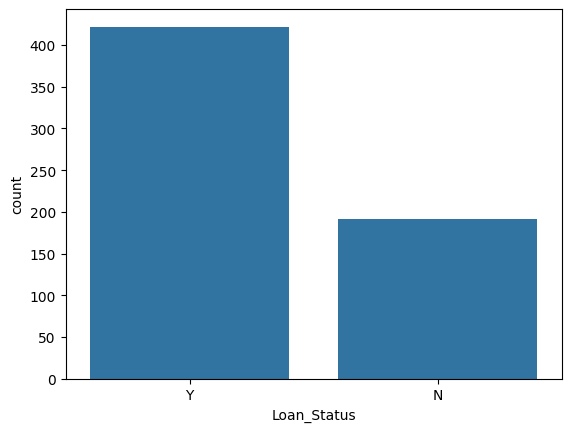

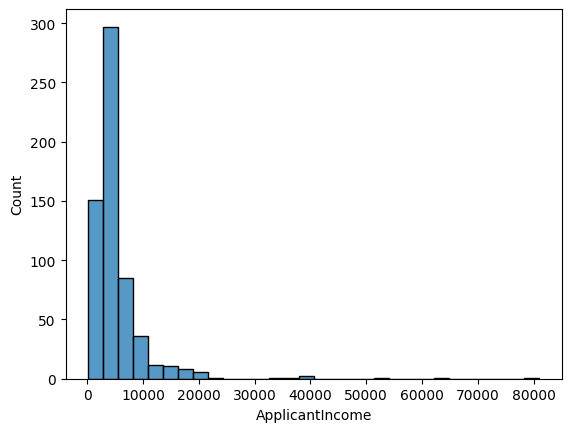

ValueError: could not convert string to float: 'LP002467'

In [4]:


from google.colab import files
uploaded = files.upload()
import pandas as pd
import os

# automatically pick uploaded csv file
file_name = list(uploaded.keys())[0]
print("Using file:", file_name)

df = pd.read_csv(file_name)
df.head()
df.isnull().sum()
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['Loan_Status'])
plt.show()
sns.histplot(df['ApplicantIncome'], bins=30)
plt.show()
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['Gender','Married','Education','Self_Employed','Property_Area','Loan_Status']

for col in cols:
    df[col] = le.fit_transform(df[col])
    from sklearn.model_selection import train_test_split

X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)